In [104]:
%pip install numpy pandas matplotlib seaborn scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats

In [106]:
### CONFIG ###
wc_add_file = "wc_a100_add_u64_sweep.csv"
wc_contains_file = "wc_a100_contains_u64_sweep.csv"
pfp_add_file = "pfp_a100_add_u64_sweep.csv"
pfp_contains_file = "pfp_a100_contains_u64_sweep.csv"

filter_sizes_mb = [1, 1024]
block_bits = [32, 64, 128, 256, 512]
word_bits = 64 # Adding here for convenience
### END CONFIG ###

In [107]:
# Load data
wc_add = pd.read_csv(wc_add_file)
wc_contains = pd.read_csv(wc_contains_file)
pfp_add = pd.read_csv(pfp_add_file)
pfp_contains = pd.read_csv(pfp_contains_file)

In [108]:
# Sanity check that the FPR is the same for all configurations (for some choice of filter size, etc.)
examine = pfp_contains[(pfp_contains['BlockBits'] == 256) 
                       & (pfp_contains['PatternBitsPerWord'] == 1) 
                       & (pfp_contains['Skipped'] == 'No')
                       & (pfp_contains['FilterSizeMB'] == 1)]
pd.set_option('display.max_rows', None)
print(examine[['HorizontalLayout', 'VerticalLayout', 'FalsePositiveRate']])

      HorizontalLayout  VerticalLayout  FalsePositiveRate
1152                 1               1           0.026617
1164                 1               2           0.026617
1176                 1               4           0.026617
1200                 2               1           0.026617
1212                 2               2           0.026617
1248                 4               1           0.026617


In [109]:
# Add throughput, log filter size
wc_add['Throughput(GK/s)'] = wc_add['Elem/s (elem/sec)'] / \
    (1024 * 1024 * 1024)
wc_contains['Throughput(GK/s)'] = wc_contains['Elem/s (elem/sec)'] / \
    (1024 * 1024 * 1024)
pfp_add['Throughput(GK/s)'] = pfp_add['Elem/s (elem/sec)'] / \
    (1024 * 1024 * 1024)
pfp_contains['Throughput(GK/s)'] = pfp_contains['Elem/s (elem/sec)'] / (
    1024 * 1024 * 1024)
wc_add['Log2FilterBytes'] = wc_add['FilterSizeMB'].apply(
    lambda x: int(math.log2(x * 1024 * 1024)))
wc_contains['Log2FilterBytes'] = wc_contains['FilterSizeMB'].apply(
    lambda x: int(math.log2(x * 1024 * 1024)))
pfp_add['Log2FilterBytes'] = pfp_add['FilterSizeMB'].apply(
    lambda x: int(math.log2(x * 1024 * 1024)))
pfp_contains['Log2FilterBytes'] = pfp_contains['FilterSizeMB'].apply(
    lambda x: int(math.log2(x * 1024 * 1024)))

In [ ]:
# Filter to the desired filter sizes and remove skipped benchmarks
wc_add = wc_add[wc_add['FilterSizeMB'].isin(filter_sizes_mb)
                & (wc_add['Skipped'] == 'No')
                & (wc_add['BlockBits'].isin(block_bits))]
wc_contains = wc_contains[wc_contains['FilterSizeMB'].isin(filter_sizes_mb)
                          & (wc_contains['Skipped'] == 'No')
                          & (wc_contains['BlockBits'].isin(block_bits))
                          & ((wc_contains['BlockBits'] < 512) 
                            | (wc_contains['PatternBitsPerWord'] == 1))]
pfp_add = pfp_add[pfp_add['FilterSizeMB'].isin(filter_sizes_mb)
                  & (pfp_add['Skipped'] == 'No')
                  & (pfp_add['BlockBits'].isin(block_bits))]
pfp_contains = pfp_contains[pfp_contains['FilterSizeMB'].isin(filter_sizes_mb)
                            & (pfp_contains['Skipped'] == 'No')
                            & (pfp_contains['BlockBits'].isin(block_bits))]

In [111]:
# Get metadata (assume all input files generated by the same machine)
machine = wc_add['Device Name'].iloc[0]
word = wc_add['Word'].iloc[0]
pattern_bits_per_word = sorted(wc_add['PatternBitsPerWord'].unique())

In [112]:
# Filter to the best configurations
best_pfp_add = (pfp_add.sort_values('Throughput(GK/s)', ascending=False)
                       .groupby(['FilterSizeMB', 'BlockBits', 'PatternBitsPerWord'], 
                                 as_index=False)
                       .first())
best_pfp_contains = (pfp_contains.sort_values('Throughput(GK/s)', ascending=False)
                                 .groupby(['FilterSizeMB', 'BlockBits', 'PatternBitsPerWord'], 
                                           as_index=False)
                                 .first())

In [113]:
# Print the best configuratiions
display_cols = ['Benchmark', 'PatternBitsPerWord', 'BlockBits',
                'HorizontalLayout', 'VerticalLayout', 'FilterSizeMB', 'Throughput(GK/s)']
print(best_pfp_add[display_cols])
print(best_pfp_contains[display_cols])

                               Benchmark  PatternBitsPerWord  BlockBits  \
0   pfp_bloom_filter_add_unique_size_u64                   1         64   
1   pfp_bloom_filter_add_unique_size_u64                  16         64   
2   pfp_bloom_filter_add_unique_size_u64                   1        128   
3   pfp_bloom_filter_add_unique_size_u64                  16        128   
4   pfp_bloom_filter_add_unique_size_u64                   1        256   
5   pfp_bloom_filter_add_unique_size_u64                  16        256   
6   pfp_bloom_filter_add_unique_size_u64                   1        512   
7   pfp_bloom_filter_add_unique_size_u64                   1         64   
8   pfp_bloom_filter_add_unique_size_u64                  16         64   
9   pfp_bloom_filter_add_unique_size_u64                   1        128   
10  pfp_bloom_filter_add_unique_size_u64                  16        128   
11  pfp_bloom_filter_add_unique_size_u64                   1        256   
12  pfp_bloom_filter_add_

In [114]:
# Define the theoretical FPR functions
# Traditional
def theoretical_fpr_std(m, n, k):
    return np.pow(1 - np.pow(1 - (1 / m), k * n), k)

# Blocked
def theoretical_fpr_blocked(m_over_n, k, B, max_i=1000, tol=1e-20):
    result = 0.0
    for i in range(max_i):
        p = stats.poisson.pmf(i, B / m_over_n)
        if p < tol:
            break
        result += p * theoretical_fpr_std(B, i, k)
    return result

# Sectorized
def theoretical_fpr_sectorized(m_over_n, k, B, S, max_i=1000, tol=1e-20):
    result = 0.0
    s = B // S
    for i in range(max_i):
        p = stats.poisson.pmf(i, B / m_over_n)
        if p < tol:
            break
        f_sector = theoretical_fpr_std(S, i, k / s)
        result += p * np.pow(f_sector, s)
    return result

In [115]:
# Stack wc and pfp
contains_stacked = pd.concat([wc_contains, best_pfp_contains])

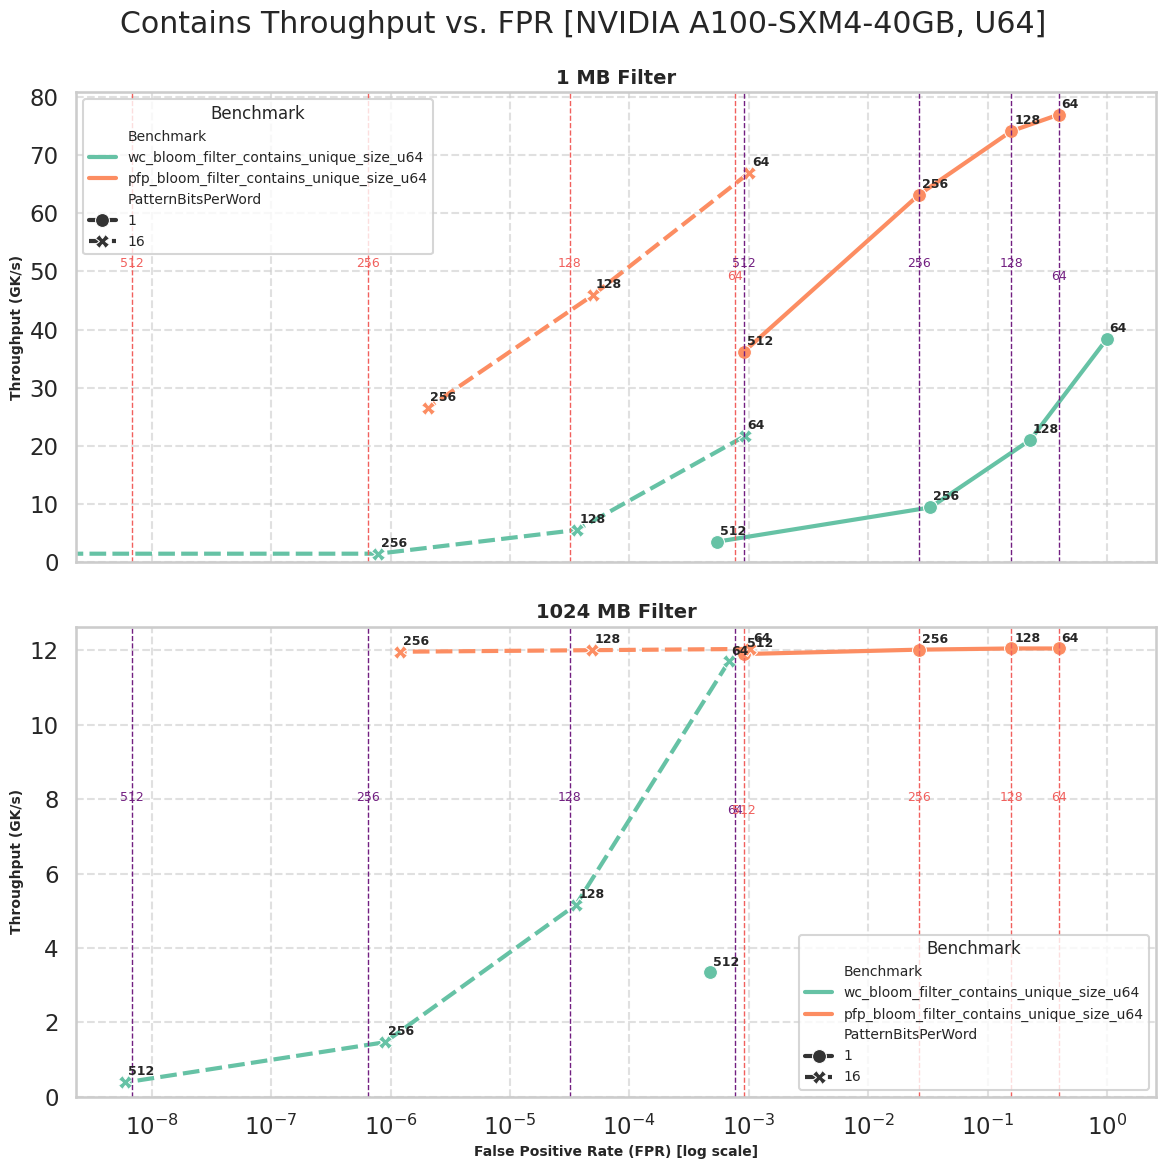

In [ ]:
# Plot
sns.set_style("whitegrid")
sns.set_context("talk")

fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

for i, filter_size in enumerate(filter_sizes_mb):
    subset = contains_stacked[(contains_stacked['FilterSizeMB'] == filter_size)]
    sns.lineplot(
        data=subset,
        x='FalsePositiveRate',
        y='Throughput(GK/s)',
        sort=False,
        hue='Benchmark',
        style='PatternBitsPerWord',
        markers=True,
        dashes=True,
        palette='Set2',
        linewidth=3,
        markersize=10,
        ax=axes[i]
    )

    pattern_bits_per_word_values = subset['PatternBitsPerWord'].unique()
    n_pattern_bits_per_word_values = len(pattern_bits_per_word_values)
    palette = sns.color_palette(
        'magma', n_colors=n_pattern_bits_per_word_values)
    for pattern_bits_per_word, k_color in zip(pattern_bits_per_word_values, palette):
        sub_subset = subset[subset['PatternBitsPerWord']
                            == pattern_bits_per_word]
        for j, block_bits in enumerate(sub_subset['BlockBits'].unique()):
            pattern_bits = pattern_bits_per_word * (block_bits / word_bits)
            sectorized_fpr = theoretical_fpr_sectorized(2 * pattern_bits,
                                                        pattern_bits,
                                                        block_bits,
                                                        word_bits)
            axes[i].axvline(sectorized_fpr,
                            color=k_color,
                            linestyle='--',
                            linewidth=1)
            axes[i].annotate(f"{block_bits}",
                             xy=(sectorized_fpr, axes[i].get_ylim()[1] / 1.5),
                             xycoords='data',
                             xytext=(0, -15),
                             textcoords='offset points',
                             ha='center',
                             va='top' if j == 0 else 'bottom',
                             fontsize=9,
                             color=k_color,
                             rotation=0)

    for _, row in subset.iterrows():
        axes[i].annotate(
            f"{int(row['BlockBits'])}",
            (row['FalsePositiveRate'], row['Throughput(GK/s)']),
            textcoords='offset points',
            xytext=(2, 5),
            ha='left',
            fontsize=9,
            weight='bold'
        )

    axes[i].set_xscale('log')
    axes[i].set_xlabel(
        'False Positive Rate (FPR) [log scale]', fontsize=10, weight='bold')
    axes[i].set_ylabel('Throughput (GK/s)', fontsize=10, weight='bold')
    axes[i].set_ylim(bottom=0)
    axes[i].set_title(f'{filter_size} MB Filter',
                      fontsize=14, weight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend(title='Benchmark', title_fontsize='12', fontsize='10')

plt.suptitle(f'Contains Throughput vs. FPR [{machine}, {word}]')
plt.tight_layout()
plt.show()